# Notebook 01 — Exploratory Data Analysis

**Project:** India Gold Import Duty Hike — Pass-Through Study  
**Input:** `data/gold_policy_clean.csv` (output of `00_data_pipeline.ipynb`)  
**Purpose:** Understand the data before touching any regression.

### Sequence
1. Load & inspect the clean dataset
2. Premium time series — full sample, annotated
3. Pre/post distribution comparison
4. Correlation heatmap (regressors)
5. Policy window close-up (±30 trading days)
6. Stationarity & ACF/PACF of the premium series
7. Gold_USD and FX series — verify no structural break confounds
8. RBI forex reserves around the event
9. Silver premium vs gold premium (placebo preview)
10. Summary statistics table (paper-ready)

In [1]:
# ── Cell 1: Load clean dataset + basic inspection ────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR  = Path('../data')
FIG_DIR   = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

POLICY_DATE = pd.Timestamp('2026-05-13')

df = pd.read_csv(DATA_DIR / 'gold_policy_clean.csv',
                 index_col='date', parse_dates=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns    : {list(df.columns)}')
print(f'\nPolicy date: {POLICY_DATE.date()}')
pre_n  = df.loc[df.index <  POLICY_DATE, 'domestic_premium'].notna().sum()
post_n = df.loc[df.index >= POLICY_DATE, 'domestic_premium'].notna().sum()
print(f'Pre-hike  domestic_premium non-NaN: {pre_n}')
print(f'Post-hike domestic_premium non-NaN: {post_n}')
print()
print('--- dtypes ---')
print(df.dtypes)
print()
cols = ['Gold_INR_actual','Gold_USD','rupees_per_dollar',
        'parity_pre','domestic_premium','premium_pct','post_hike']
print('--- first 3 rows ---')
print(df[cols].head(3).to_string())
print()
print('--- last 3 rows ---')
print(df[cols].tail(3).to_string())

Shape      : (1157, 24)
Date range : 2022-01-03 → 2026-06-10
Columns    : ['Oil_USD', 'Gold_USD', 'rupees_per_dollar', 'Kalyan', 'Silver_USD', 'Nifty50', 'US10Y_yield', 'MCX_Gold', 'GOLDBEES', 'Gold_INR_actual', 'Silver_INR_actual', 'ibja_source', 'forex_reserves_usd_bn', 'domestic_premium', 'premium_pct', 'silver_premium', 'post_hike', 'days_since_hike', 'delta_Gold_USD', 'delta_FX', 'delta_Oil', 'parity_pre', 'parity_post', 'silver_parity_pre']

Policy date: 2026-05-13
Pre-hike  domestic_premium non-NaN: 751
Post-hike domestic_premium non-NaN: 18

--- dtypes ---
Oil_USD                  float64
Gold_USD                 float64
rupees_per_dollar        float64
Kalyan                   float64
Silver_USD               float64
Nifty50                  float64
US10Y_yield              float64
MCX_Gold                 float64
GOLDBEES                 float64
Gold_INR_actual          float64
Silver_INR_actual        float64
ibja_source                  str
forex_reserves_usd_bn    float64


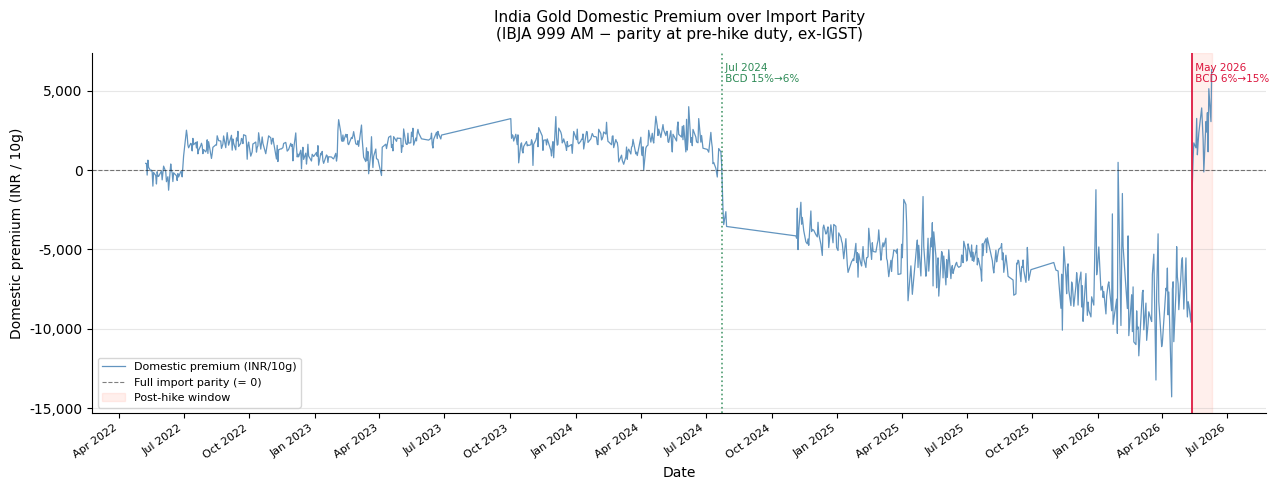

Saved → ../figures/fig01_premium_timeseries.png

--- Sub-period premium means ---
  Pre-cut    (Jan 2022 – Jul 2024)  n= 430  mean=   1,493  std=    809
  Low-duty   (Jul 2024 – May 2026)  n= 321  mean=  -6,093  std=  2,067
  Post-hike  (May 2026 – present)   n=  18  mean=   2,322  std=  1,768


In [3]:
# ── Cell 2: Premium time series — full sample, annotated ────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 5))

# ── Plot premium series ───────────────────────────────────────────────────
prem = df['domestic_premium'].dropna()
ax.plot(prem.index, prem.values, color='steelblue', linewidth=0.9,
        alpha=0.85, label='Domestic premium (INR/10g)')

# ── Zero line (full import parity) ───────────────────────────────────────
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
           label='Full import parity (= 0)')

# ── Shade post-hike window ────────────────────────────────────────────────
ax.axvspan(POLICY_DATE, df.index.max(), alpha=0.10, color='tomato',
           label='Post-hike window')

# ── Key event lines ───────────────────────────────────────────────────────
# July 23, 2024: Union Budget — BCD cut from 15% to 6%
duty_cut_date = pd.Timestamp('2024-07-23')
ax.axvline(duty_cut_date, color='seagreen', linewidth=1.2,
           linestyle=':', alpha=0.85)
ax.text(duty_cut_date, ax.get_ylim()[1] * 0.92,
        ' Jul 2024\n BCD 15%→6%',
        fontsize=7.5, color='seagreen', va='top')

# May 13, 2026: hike announcement
ax.axvline(POLICY_DATE, color='crimson', linewidth=1.4, linestyle='-', alpha=0.9)
ax.text(POLICY_DATE, ax.get_ylim()[1] * 0.92,
        ' May 2026\n BCD 6%→15%',
        fontsize=7.5, color='crimson', va='top')

# ── Formatting ────────────────────────────────────────────────────────────
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('India Gold Domestic Premium over Import Parity\n'
             '(IBJA 999 AM − parity at pre-hike duty, ex-IGST)',
             fontsize=11, pad=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=35, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8, loc='lower left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
out = FIG_DIR / 'fig01_premium_timeseries.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Quick print: notable sub-periods ─────────────────────────────────────
print('\n--- Sub-period premium means ---')
periods = [
    ('Pre-cut    (Jan 2022 – Jul 2024)', '2022-01-01', '2024-07-22'),
    ('Low-duty   (Jul 2024 – May 2026)', '2024-07-23', '2026-05-12'),
    ('Post-hike  (May 2026 – present) ', '2026-05-13', '2099-01-01'),
]
for label, start, end in periods:
    sub = df.loc[start:end, 'domestic_premium'].dropna()
    print(f'  {label}  n={len(sub):>4}  '
          f'mean={sub.mean():>8,.0f}  std={sub.std():>7,.0f}')

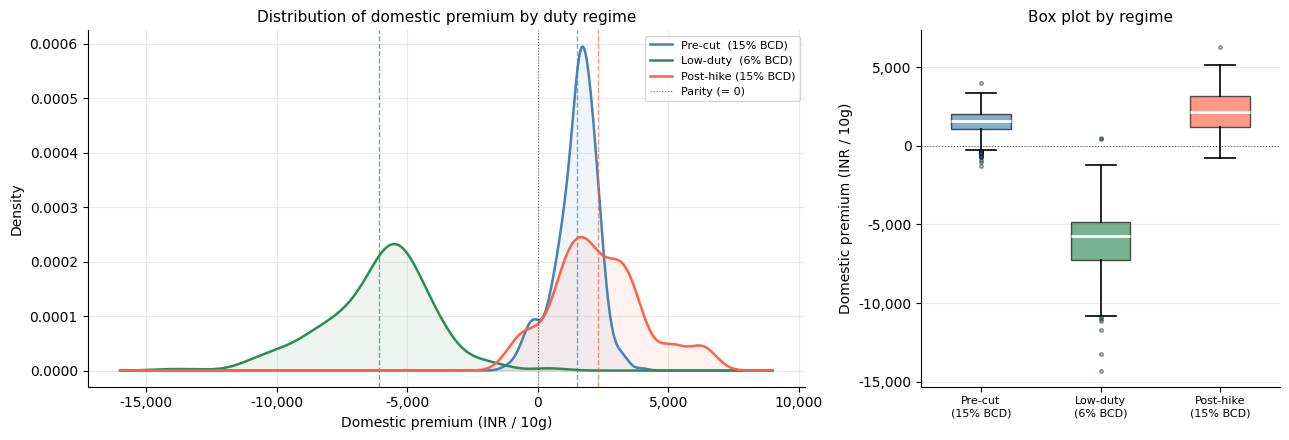

Saved → ../figures/fig02_premium_distributions.png

--- Regime summary statistics ---
Pre-cut  (15% BCD)            n= 430  mean=   1,493  median=   1,616  std=    809  p10=     399  p90=   2,357
Low-duty  (6% BCD)            n= 321  mean=  -6,093  median=  -5,764  std=  2,067  p10=  -8,845  p90=  -3,821
Post-hike (15% BCD)           n=  18  mean=   2,322  median=   2,164  std=  1,768  p10=     469  p90=   4,276

Welch t-test  low-duty vs post-hike:
  t = -19.462   p = 0.0000   (diff in means = 8,415 INR/10g)


In [6]:
# ── Cell 3: Pre/post distribution comparison ─────────────────────────────
# KDE + histogram overlay of domestic_premium for three regimes.
# Vertical lines show regime means.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

# ── Three regime slices ───────────────────────────────────────────────────
pre_cut   = df.loc['2022-01-01':'2024-07-22', 'domestic_premium'].dropna()
low_duty  = df.loc['2024-07-23':'2026-05-12', 'domestic_premium'].dropna()
post_hike = df.loc['2026-05-13':,             'domestic_premium'].dropna()

regimes = [
    (pre_cut,   'Pre-cut  (15% BCD)',  'steelblue',  '///'),
    (low_duty,  'Low-duty  (6% BCD)',  'seagreen',   '...'),
    (post_hike, 'Post-hike (15% BCD)', 'tomato',     'xxx'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                         gridspec_kw={'width_ratios': [2, 1]})

# ── Left panel: KDE ───────────────────────────────────────────────────────
ax = axes[0]
x_grid = np.linspace(-16000, 9000, 500)
for data, label, color, _ in regimes:
    if len(data) < 5:
        continue
    kde = gaussian_kde(data, bw_method=0.3)
    ax.plot(x_grid, kde(x_grid), color=color, linewidth=1.8, label=label)
    ax.axvline(data.mean(), color=color, linewidth=1.0,
               linestyle='--', alpha=0.7)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.08, color=color)

ax.axvline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.6,
           label='Parity (= 0)')
ax.set_xlabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Distribution of domestic premium by duty regime', fontsize=11)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.25)
ax.spines[['top','right']].set_visible(False)

# ── Right panel: box plot ─────────────────────────────────────────────────
ax2 = axes[1]
colors  = ['steelblue', 'seagreen', 'tomato']
labels  = ['Pre-cut\n(15% BCD)', 'Low-duty\n(6% BCD)', 'Post-hike\n(15% BCD)']
data_bp = [pre_cut.values, low_duty.values, post_hike.values]

bp = ax2.boxplot(data_bp, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2),
                 flierprops=dict(marker='o', markersize=2.5,
                                alpha=0.4, linestyle='none'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)

ax2.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax2.set_title('Box plot by regime', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
out = FIG_DIR / 'fig02_premium_distributions.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Summary stats per regime ──────────────────────────────────────────────
print('\n--- Regime summary statistics ---')
fmt = '{:<28}  n={:>4}  mean={:>8,.0f}  median={:>8,.0f}  std={:>7,.0f}  '\
      'p10={:>8,.0f}  p90={:>8,.0f}'
for data, label, *_ in regimes:
    print(fmt.format(label, len(data), data.mean(), data.median(),
                     data.std(), data.quantile(0.10), data.quantile(0.90)))

# ── Welch t-test: low-duty vs post-hike ──────────────────────────────────
from scipy.stats import ttest_ind
t, p = ttest_ind(low_duty, post_hike, equal_var=False)
print(f'\nWelch t-test  low-duty vs post-hike:')
print(f'  t = {t:.3f}   p = {p:.4f}   '
      f'(diff in means = {post_hike.mean() - low_duty.mean():,.0f} INR/10g)')

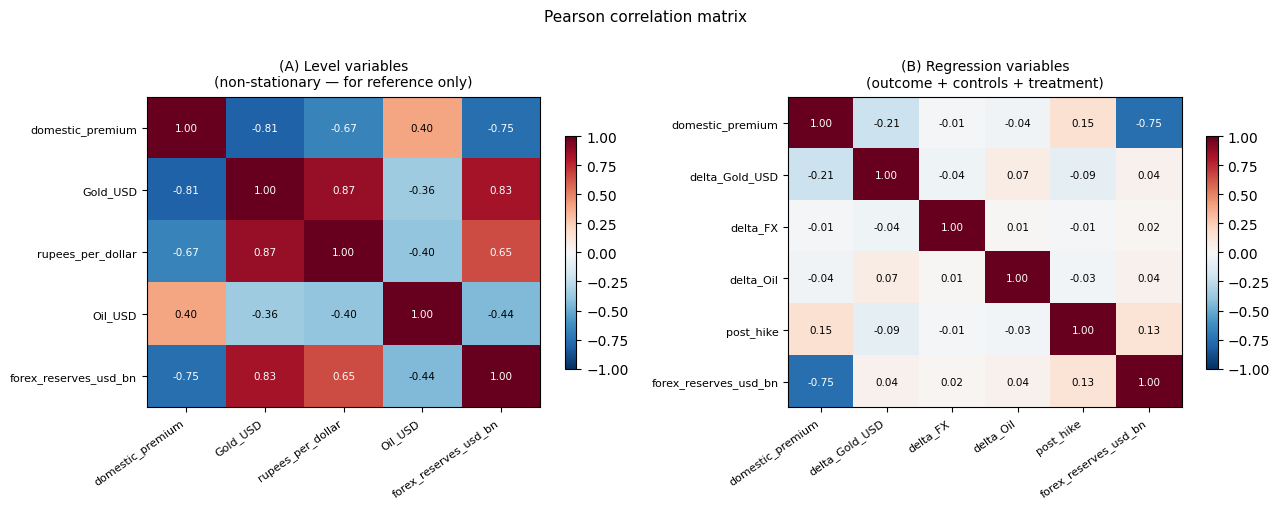

Saved → ../figures/fig03_correlation_heatmap.png

--- Correlation with domestic_premium ---
  delta_Gold_USD                  r = -0.211
  delta_FX                        r = -0.008
  delta_Oil                       r = -0.039
  post_hike                       r = +0.152
  forex_reserves_usd_bn           r = -0.754

--- Variance Inflation Factor (VIF) for regression controls ---
  delta_Gold_USD                  VIF = 1.02
  delta_FX                        VIF = 1.00
  delta_Oil                       VIF = 1.01
  post_hike                       VIF = 1.03
  forex_reserves_usd_bn           VIF = 1.02


In [8]:
# ── Cell 4: Correlation heatmap (regressors) ─────────────────────────────
# Purpose: check for multicollinearity among the variables we plan to use
# in the ITS regression before we ever touch the regression itself.
#
# Regression spec (reminder):
#   premium_t = α + β1·post_hike + β2·t + β3·δGold_USD + β4·δFX + ε
# Additional candidates: δOil, forex_reserves_usd_bn, Silver premium
#
# We look at TWO sets:
#   (A) Level variables — domestic_premium, Gold_USD, rupees_per_dollar,
#       Oil_USD, forex_reserves_usd_bn
#   (B) Change/regression variables — domestic_premium, delta_Gold_USD,
#       delta_FX, delta_Oil, post_hike

import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(ax, corr, title):
    n = len(corr)
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    for i in range(n):
        for j in range(n):
            val = corr.iloc[i, j]
            txt_color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color=txt_color)
    ax.set_title(title, fontsize=10, pad=8)
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: level variables ──────────────────────────────────────────────
level_cols = ['domestic_premium', 'Gold_USD', 'rupees_per_dollar',
              'Oil_USD', 'forex_reserves_usd_bn']
corr_A = df[level_cols].corr()
im = plot_heatmap(axes[0], corr_A,
    '(A) Level variables\n(non-stationary — for reference only)')
plt.colorbar(im, ax=axes[0], shrink=0.75)

# ── Panel B: regression variables (changes + treatment) ──────────────────
reg_cols = ['domestic_premium', 'delta_Gold_USD', 'delta_FX',
            'delta_Oil', 'post_hike', 'forex_reserves_usd_bn']
corr_B = df[reg_cols].corr()
im2 = plot_heatmap(axes[1], corr_B,
    '(B) Regression variables\n(outcome + controls + treatment)')
plt.colorbar(im2, ax=axes[1], shrink=0.75)

plt.suptitle('Pearson correlation matrix', fontsize=11, y=1.01)
plt.tight_layout()
out = FIG_DIR / 'fig03_correlation_heatmap.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Print correlation of each regressor with domestic_premium ─────────────
print('\n--- Correlation with domestic_premium ---')
for col in reg_cols[1:]:
    r = df[['domestic_premium', col]].dropna().corr().iloc[0, 1]
    print(f'  {col:<30}  r = {r:+.3f}')

# ── VIF check on regression controls ─────────────────────────────────────
print('\n--- Variance Inflation Factor (VIF) for regression controls ---')
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_cols = ['delta_Gold_USD', 'delta_FX', 'delta_Oil',
            'post_hike', 'forex_reserves_usd_bn']
vif_data = df[vif_cols].dropna()
X_vif = sm.add_constant(vif_data)
for i, col in enumerate(X_vif.columns[1:], start=1):
    vif = variance_inflation_factor(X_vif.values, i)
    flag = '  ⚠  (>5)' if vif > 5 else ''
    print(f'  {col:<30}  VIF = {vif:.2f}{flag}')

Window: 2026-04-01 → 2026-06-10
Pre-hike days in window : 30
Post-hike days in window: 21 (all available)


/var/folders/dr/4hb3w_yn2xq77d2njhl6shph0000gn/T/ipykernel_53238/2835732299.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


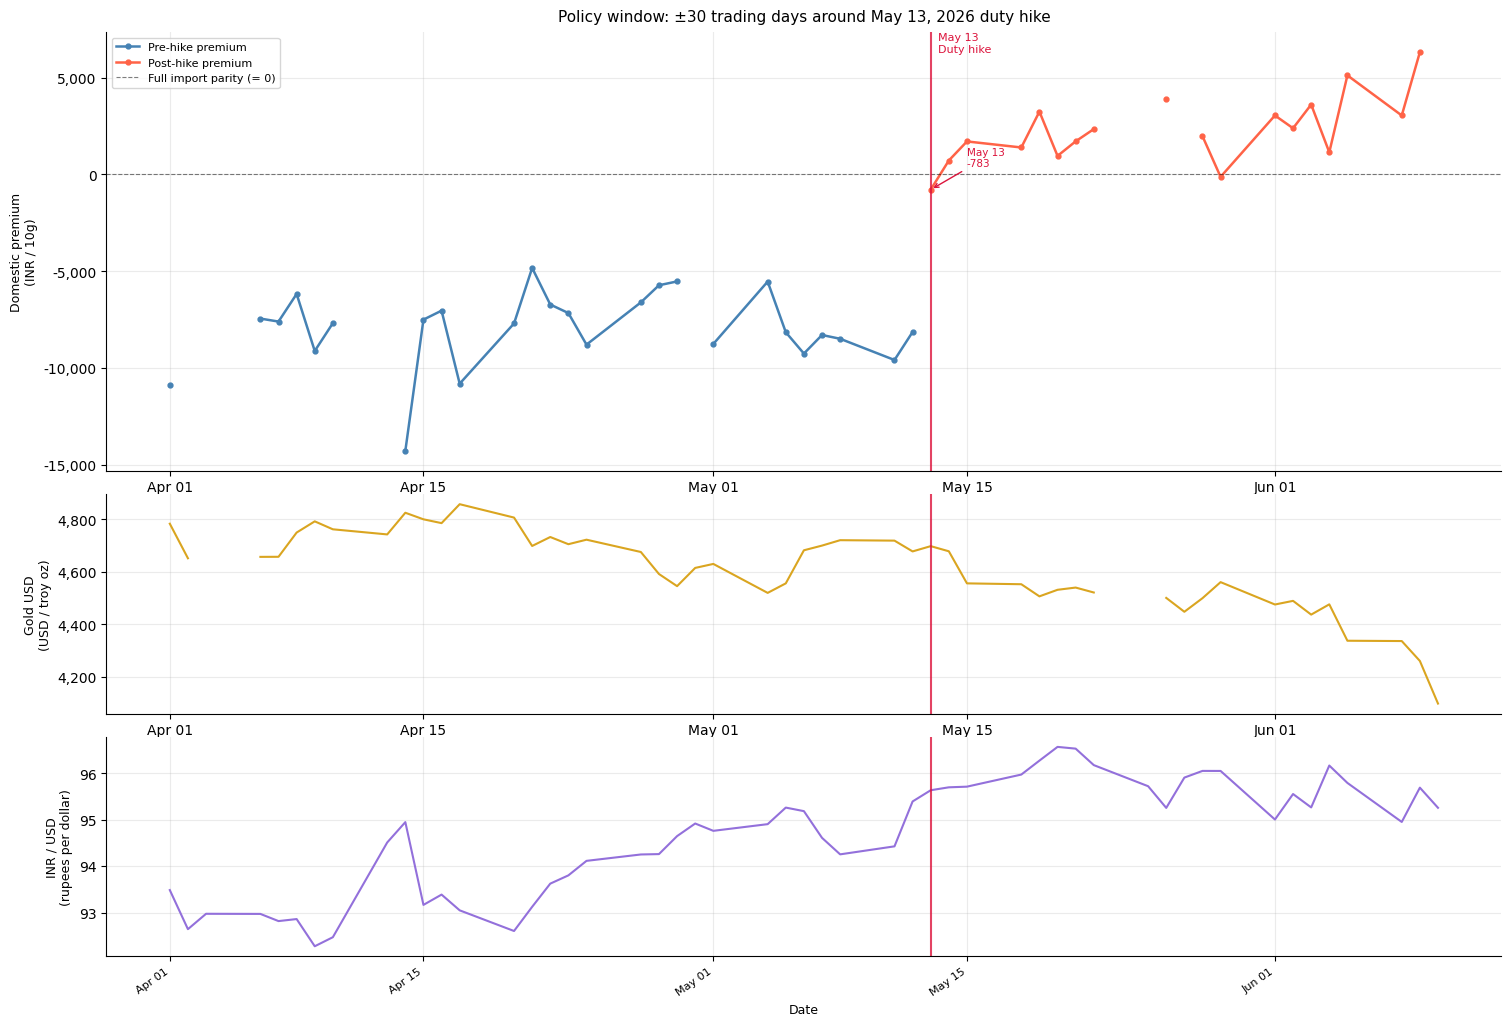

Saved → ../figures/fig04_policy_window.png

--- Day-by-day: 5 pre + all post-hike ---
            Gold_INR_actual  Gold_USD  rupees_per_dollar  parity_pre  domestic_premium  premium_pct  post_hike
date                                                                                                          
2026-05-06        150,636.0   4,681.9               95.2   159,895.6          -9,259.6         -5.8          0
2026-05-07        151,237.0   4,699.8               94.6   159,537.3          -8,300.3         -5.2          0
2026-05-08        151,140.0   4,720.4               94.3   159,635.3          -8,495.3         -5.3          0
2026-05-11        150,277.0   4,718.7               94.4   159,869.5          -9,592.5         -6.0          0
2026-05-12        151,954.0   4,677.6               95.4   160,098.5          -8,144.5         -5.1          0
2026-05-13        160,411.0   4,697.7               95.6   161,193.7            -782.7         -0.5          1
2026-05-14        161,349.

In [10]:
# ── Cell 5: Policy window close-up (±30 trading days) ───────────────────
# Zooms into the event window to show:
#   1. The premium trajectory in the 30 days before the hike
#   2. The jump and subsequent path in the 30 days after
#   3. parity_pre as a reference line (= 0 baseline)
#   4. Gold_USD and FX on secondary axes to show concurrent moves

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# ── Build window ──────────────────────────────────────────────────────────
# 30 trading days before and after policy date
all_dates = df.index[df.index <= POLICY_DATE + pd.tseries.offsets.BDay(35)]
pre_dates  = df.index[df.index < POLICY_DATE]
post_dates = df.index[df.index >= POLICY_DATE]

# Get the 30 trading days on each side
pre_window  = pre_dates[-30:]
post_window = post_dates[:30]   # we only have 18 so far
window_idx  = pre_window.union(post_window)
w = df.loc[window_idx]

print(f'Window: {window_idx[0].date()} → {window_idx[-1].date()}')
print(f'Pre-hike days in window : {len(pre_window)}')
print(f'Post-hike days in window: {len(post_window)} (all available)')

# ── Figure: 3 stacked panels ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 1, hspace=0.08, height_ratios=[3, 1.5, 1.5])

# ── Panel 1: domestic premium ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

pre_prem  = w.loc[w.index < POLICY_DATE, 'domestic_premium']
post_prem = w.loc[w.index >= POLICY_DATE, 'domestic_premium']

ax1.plot(pre_prem.index,  pre_prem.values,
         color='steelblue', linewidth=1.8, marker='o', markersize=3.5,
         label='Pre-hike premium')
ax1.plot(post_prem.index, post_prem.values,
         color='tomato', linewidth=1.8, marker='o', markersize=3.5,
         label='Post-hike premium')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
            label='Full import parity (= 0)')
ax1.axvline(POLICY_DATE, color='crimson', linewidth=1.5, alpha=0.8)
ax1.text(POLICY_DATE, ax1.get_ylim()[1],
         '  May 13\n  Duty hike', fontsize=8, color='crimson', va='top')

# Annotate the May 13 point specifically
may13_prem = w.loc['2026-05-13', 'domestic_premium']
ax1.annotate(f'May 13\n{may13_prem:,.0f}',
             xy=(pd.Timestamp('2026-05-13'), may13_prem),
             xytext=(pd.Timestamp('2026-05-13') + pd.tseries.offsets.BDay(2),
                     may13_prem + 1200),
             fontsize=7.5, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0))

ax1.set_ylabel('Domestic premium\n(INR / 10g)', fontsize=9)
ax1.set_title('Policy window: ±30 trading days around May 13, 2026 duty hike',
              fontsize=11, pad=8)
ax1.legend(fontsize=8, loc='upper left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)
ax1.set_xticklabels([])

# ── Panel 2: Gold_USD ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(w.index, w['Gold_USD'], color='goldenrod', linewidth=1.5)
ax2.axvline(POLICY_DATE, color='crimson', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Gold USD\n(USD / troy oz)', fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(alpha=0.25)
ax2.spines[['top','right']].set_visible(False)
ax2.set_xticklabels([])

# ── Panel 3: rupees_per_dollar ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(w.index, w['rupees_per_dollar'], color='mediumpurple', linewidth=1.5)
ax3.axvline(POLICY_DATE, color='crimson', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('INR / USD\n(rupees per dollar)', fontsize=9)
ax3.set_xlabel('Date', fontsize=9)
ax3.grid(alpha=0.25)
ax3.spines[['top','right']].set_visible(False)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)

plt.tight_layout()
out = FIG_DIR / 'fig04_policy_window.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Day-by-day table around the event ────────────────────────────────────
print('\n--- Day-by-day: 5 pre + all post-hike ---')
event_cols = ['Gold_INR_actual','Gold_USD','rupees_per_dollar',
              'parity_pre','domestic_premium','premium_pct','post_hike']
event_window = df.loc[
    pre_window[-5:].union(post_window), event_cols
]
pd.set_option('display.float_format', '{:,.1f}'.format)
print(event_window.to_string())

Pre-hike premium series: n = 751
  2022-05-09 → 2026-05-12

=== Augmented Dickey-Fuller test ===
H0: series has a unit root (non-stationary)

  Spec: constant only
  ADF statistic : -0.0619
  p-value       : 0.9531
  Lags used     : 16
  Critical values: 1%=-3.439  5%=-2.865  10%=-2.569
  Conclusion    : FAIL TO REJECT H0 → unit root (p=0.9531)

  Spec: constant + trend
  ADF statistic : -2.4038
  p-value       : 0.3776
  Lags used     : 16
  Critical values: 1%=-3.971  5%=-3.416  10%=-3.131
  Conclusion    : FAIL TO REJECT H0 → unit root (p=0.3776)

=== KPSS test ===
H0: series is stationary

  Spec: level stationary
  KPSS statistic : 3.4651
  p-value        : 0.0100
  Lags used      : 17
  Critical values: 10%=0.347  5%=0.463  1%=0.739
  Conclusion     : REJECT H0 → non-stationary (p=0.0100)

  Spec: trend stationary
  KPSS statistic : 0.7116
  p-value        : 0.0100
  Lags used      : 17
  Critical values: 10%=0.119  5%=0.146  1%=0.216
  Conclusion     : REJECT H0 → non-stationary

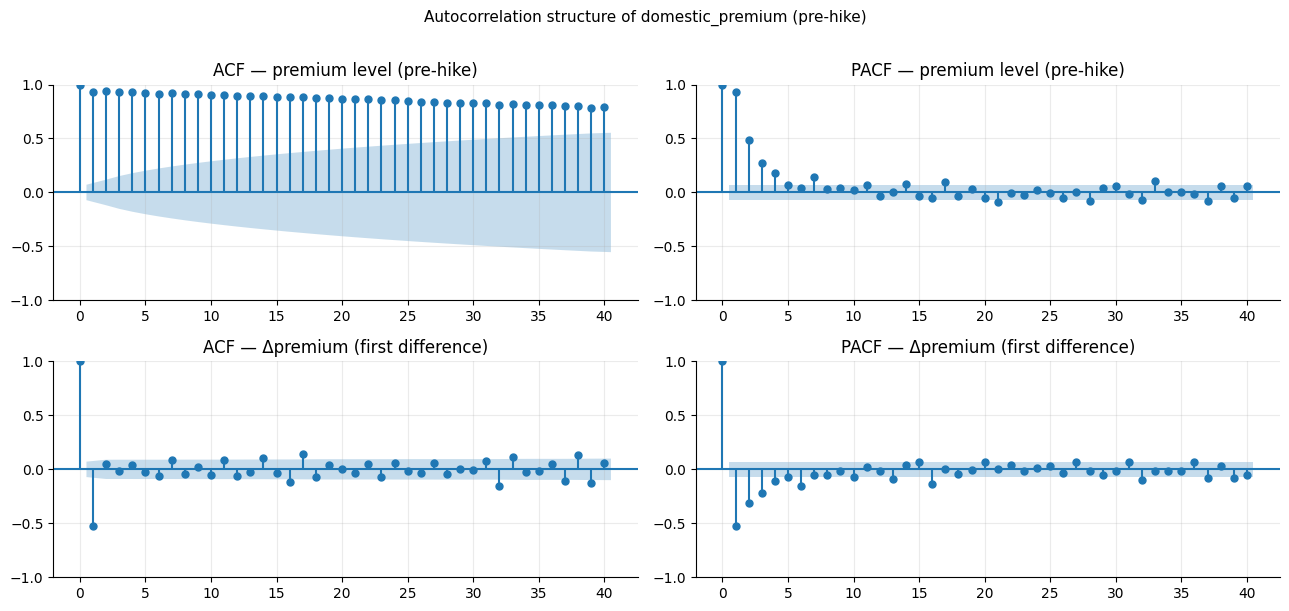


Saved → ../figures/fig05_acf_pacf.png

=== Practical implication for regression ===
If ADF rejects + KPSS fails to reject → series is I(0) → use levels
If both agree on non-stationarity    → series is I(1) → first-difference
If ADF/KPSS disagree                  → trend-stationary; include time trend
Newey-West HAC standard errors handle residual autocorrelation regardless.


In [11]:
# ── Cell 6: Stationarity tests + ACF/PACF ───────────────────────────────
# Why this matters for the regression:
#   - If domestic_premium has a unit root (random walk), OLS standard errors
#     are invalid and we need first-differences or cointegration.
#   - If it's stationary (mean-reverting), levels are fine in the ITS.
#   - ACF/PACF tells us how many lags to include for autocorrelation correction.
#
# Tests run:
#   1. Augmented Dickey-Fuller (ADF)  — H0: unit root
#   2. KPSS                           — H0: stationary
#   3. ACF / PACF plots

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# ── Clean series: pre-hike premium only, no NaN ───────────────────────────
# We test stationarity on the pre-hike series so the structural break
# (the hike itself) doesn't distort the unit-root test.
prem_pre = df.loc[df.index < POLICY_DATE, 'domestic_premium'].dropna()
print(f'Pre-hike premium series: n = {len(prem_pre)}')
print(f'  {prem_pre.index[0].date()} → {prem_pre.index[-1].date()}')

# ── 1. ADF test ───────────────────────────────────────────────────────────
print('\n=== Augmented Dickey-Fuller test ===')
print('H0: series has a unit root (non-stationary)')
for regression in ['c', 'ct']:
    label = 'constant only' if regression == 'c' else 'constant + trend'
    adf_stat, adf_p, adf_lags, _, adf_cv, _ = adfuller(
        prem_pre, autolag='AIC', regression=regression)
    print(f'\n  Spec: {label}')
    print(f'  ADF statistic : {adf_stat:.4f}')
    print(f'  p-value       : {adf_p:.4f}')
    print(f'  Lags used     : {adf_lags}')
    print(f'  Critical values: 1%={adf_cv["1%"]:.3f}  '
          f'5%={adf_cv["5%"]:.3f}  10%={adf_cv["10%"]:.3f}')
    conclusion = 'REJECT H0 → stationary' if adf_p < 0.05 else 'FAIL TO REJECT H0 → unit root'
    print(f'  Conclusion    : {conclusion} (p={adf_p:.4f})')

# ── 2. KPSS test ──────────────────────────────────────────────────────────
print('\n=== KPSS test ===')
print('H0: series is stationary')
for regression in ['c', 'ct']:
    label = 'level stationary' if regression == 'c' else 'trend stationary'
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(
        prem_pre, regression=regression, nlags='auto')
    print(f'\n  Spec: {label}')
    print(f'  KPSS statistic : {kpss_stat:.4f}')
    print(f'  p-value        : {kpss_p:.4f}')
    print(f'  Lags used      : {kpss_lags}')
    print(f'  Critical values: 10%={kpss_cv["10%"]:.3f}  '
          f'5%={kpss_cv["5%"]:.3f}  1%={kpss_cv["1%"]:.3f}')
    conclusion = ('REJECT H0 → non-stationary' if kpss_p < 0.05
                  else 'FAIL TO REJECT H0 → stationary')
    print(f'  Conclusion     : {conclusion} (p={kpss_p:.4f})')

# ── 3. ACF / PACF ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# Levels
plot_acf( prem_pre, lags=40, ax=axes[0,0], alpha=0.05,
          title='ACF — premium level (pre-hike)')
plot_pacf(prem_pre, lags=40, ax=axes[0,1], alpha=0.05, method='ywm',
          title='PACF — premium level (pre-hike)')

# First difference
prem_diff = prem_pre.diff().dropna()
plot_acf( prem_diff, lags=40, ax=axes[1,0], alpha=0.05,
          title='ACF — Δpremium (first difference)')
plot_pacf(prem_diff, lags=40, ax=axes[1,1], alpha=0.05, method='ywm',
          title='PACF — Δpremium (first difference)')

for ax in axes.flat:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.25)

plt.suptitle('Autocorrelation structure of domestic_premium (pre-hike)',
             fontsize=11, y=1.01)
plt.tight_layout()
out = FIG_DIR / 'fig05_acf_pacf.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved → {out}')

# ── Practical implication summary ─────────────────────────────────────────
print('\n=== Practical implication for regression ===')
print('If ADF rejects + KPSS fails to reject → series is I(0) → use levels')
print('If both agree on non-stationarity    → series is I(1) → first-difference')
print('If ADF/KPSS disagree                  → trend-stationary; include time trend')
print('Newey-West HAC standard errors handle residual autocorrelation regardless.')

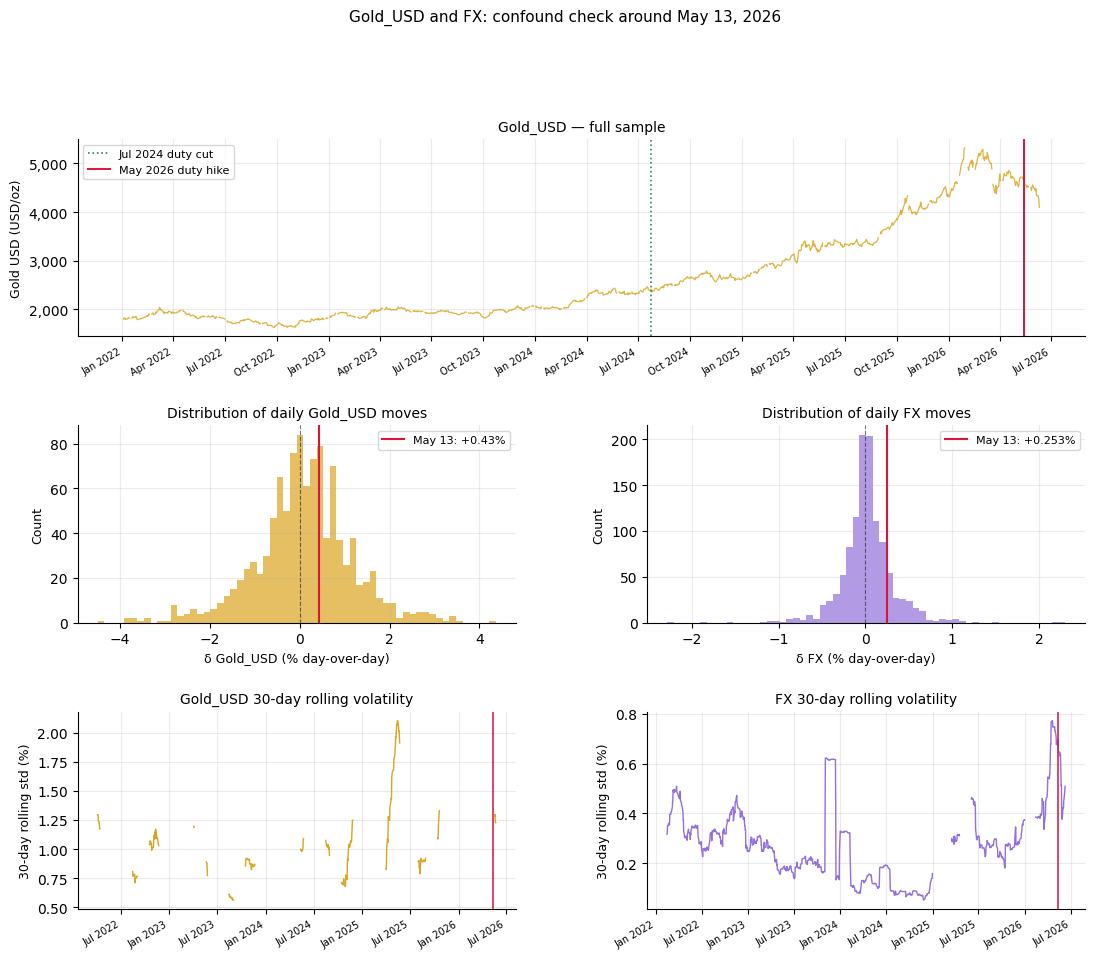

Saved → ../figures/fig06_confound_check.png

--- May 13 moves vs full-sample distribution ---

  delta_Gold_USD
    May 13 value : +0.430%
    Percentile   : 64.6th  (i.e. 65% of days had a smaller move)
    Full-sample mean : +0.093%  std: 1.094%
    Z-score      : +0.31  (ordinary if |z| < 2)

  delta_FX
    May 13 value : +0.253%
    Percentile   : 85.1th  (i.e. 85% of days had a smaller move)
    Full-sample mean : +0.022%  std: 0.315%
    Z-score      : +0.73  (ordinary if |z| < 2)


In [12]:
# ── Cell 7: Gold_USD and FX series — confound check ─────────────────────
# Question: did anything unusual happen to Gold_USD or rupees_per_dollar
# around May 13, 2026 that could independently explain the premium jump?
# If Gold_USD spiked or INR crashed on May 13, parity_pre would also jump,
# and our premium rise might partly reflect that — not the duty hike.
#
# We check:
#   1. Full-sample time series of both variables
#   2. Distribution of daily % changes (delta_Gold_USD, delta_FX)
#   3. Where May 13 sits in those distributions
#   4. Rolling 30-day volatility around the event

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)

# ── Panel 1a: Gold_USD full series ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Gold_USD'], color='goldenrod', linewidth=0.9, alpha=0.85)
ax1.axvline(pd.Timestamp('2024-07-23'), color='seagreen', linewidth=1.2,
            linestyle=':', label='Jul 2024 duty cut')
ax1.axvline(POLICY_DATE, color='crimson', linewidth=1.4,
            linestyle='-', label='May 2026 duty hike')
ax1.set_ylabel('Gold USD (USD/oz)', fontsize=9)
ax1.set_title('Gold_USD — full sample', fontsize=10)
ax1.legend(fontsize=8)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)

# ── Panel 2a: delta_Gold_USD distribution ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
dg = df['delta_Gold_USD'].dropna()
ax2.hist(dg, bins=60, color='goldenrod', alpha=0.7, edgecolor='none')
may13_dg = df.loc['2026-05-13', 'delta_Gold_USD']
ax2.axvline(may13_dg, color='crimson', linewidth=1.5,
            label=f'May 13: {may13_dg:+.2f}%')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_xlabel('δ Gold_USD (% day-over-day)', fontsize=9)
ax2.set_ylabel('Count', fontsize=9)
ax2.set_title('Distribution of daily Gold_USD moves', fontsize=10)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.25)

# ── Panel 2b: delta_FX distribution ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
dfx = df['delta_FX'].dropna()
ax3.hist(dfx, bins=60, color='mediumpurple', alpha=0.7, edgecolor='none')
may13_dfx = df.loc['2026-05-13', 'delta_FX']
ax3.axvline(may13_dfx, color='crimson', linewidth=1.5,
            label=f'May 13: {may13_dfx:+.3f}%')
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.set_xlabel('δ FX (% day-over-day)', fontsize=9)
ax3.set_ylabel('Count', fontsize=9)
ax3.set_title('Distribution of daily FX moves', fontsize=10)
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)
ax3.grid(alpha=0.25)

# ── Panel 3a: 30-day rolling vol of Gold_USD ──────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
roll_gold = df['delta_Gold_USD'].rolling(30).std()
ax4.plot(roll_gold.index, roll_gold.values, color='goldenrod', linewidth=1.0)
ax4.axvline(POLICY_DATE, color='crimson', linewidth=1.4, alpha=0.8)
ax4.set_ylabel('30-day rolling std (%)', fontsize=9)
ax4.set_title('Gold_USD 30-day rolling volatility', fontsize=10)
ax4.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
ax4.grid(alpha=0.25)
ax4.spines[['top','right']].set_visible(False)

# ── Panel 3b: 30-day rolling vol of FX ───────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
roll_fx = df['delta_FX'].rolling(30).std()
ax5.plot(roll_fx.index, roll_fx.values, color='mediumpurple', linewidth=1.0)
ax5.axvline(POLICY_DATE, color='crimson', linewidth=1.4, alpha=0.8)
ax5.set_ylabel('30-day rolling std (%)', fontsize=9)
ax5.set_title('FX 30-day rolling volatility', fontsize=10)
ax5.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
ax5.grid(alpha=0.25)
ax5.spines[['top','right']].set_visible(False)

plt.suptitle('Gold_USD and FX: confound check around May 13, 2026',
             fontsize=11, y=1.01)
plt.tight_layout()
out = FIG_DIR / 'fig06_confound_check.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Numeric summary: May 13 vs distribution ───────────────────────────────
print('\n--- May 13 moves vs full-sample distribution ---')
for label, series, may13_val in [
    ('delta_Gold_USD', dg, may13_dg),
    ('delta_FX',       dfx, may13_dfx)
]:
    pctile = (series < may13_val).mean() * 100
    print(f'\n  {label}')
    print(f'    May 13 value : {may13_val:+.3f}%')
    print(f'    Percentile   : {pctile:.1f}th  (i.e. {pctile:.0f}% of days '
          f'had a smaller move)')
    print(f'    Full-sample mean : {series.mean():+.3f}%  std: {series.std():.3f}%')
    z = (may13_val - series.mean()) / series.std()
    print(f'    Z-score      : {z:+.2f}  (ordinary if |z| < 2)')

Weekly reserves: 232 observations
Range: 2022-01-07 → 2026-06-12


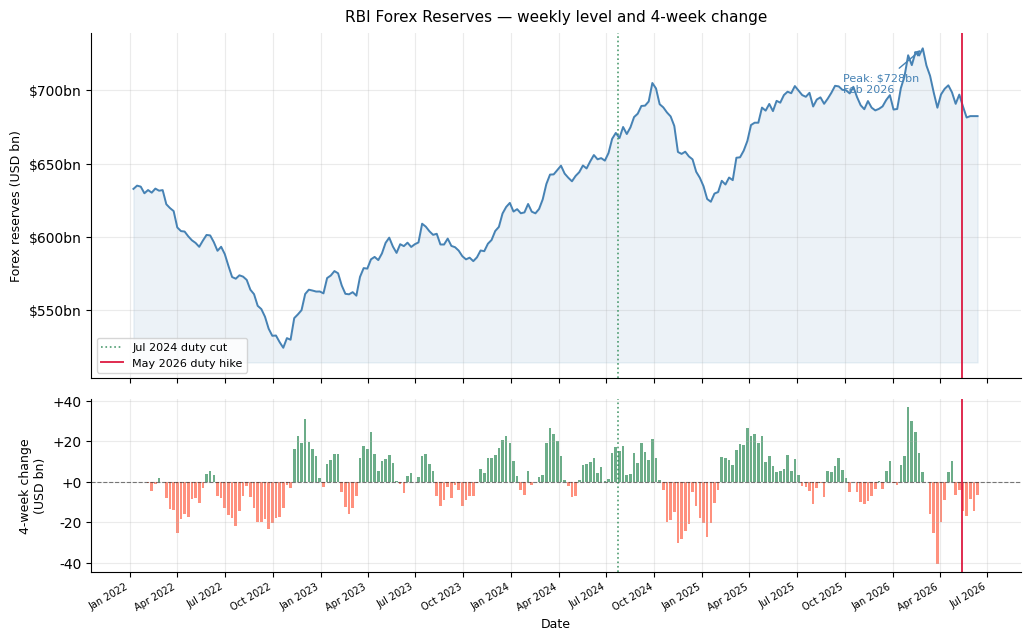

Saved → ../figures/fig07_forex_reserves.png

--- Reserves at key dates ---
  Jan 2022 (series start)       2022-01-07  $632.7bn
  Jul 2024 (duty cut)           2024-07-26  $667.4bn
  Peak                          2026-02-27  $728.5bn
  May 2026 (hike week)          2026-05-15  $688.9bn
  Latest                        2026-06-12  $682.3bn

  Drawdown peak → hike week: $-39.6bn
  (5.4% of peak reserves)


In [13]:
# ── Cell 8: RBI forex reserves around the event ──────────────────────────
# Purpose: show the macro backdrop — the RBI was burning reserves to defend
# the rupee in the lead-up to the hike. This provides narrative context for
# the FX stabilisation channel in Section 2 of the paper.
#
# forex_reserves_usd_bn is weekly data, forward-filled to daily in df.
# We plot the raw weekly series for clarity.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ── Extract weekly series (un-ffill: keep only one obs per week) ──────────
# The weekly RBI series was forward-filled. To recover weekly granularity,
# resample to weekly and take the last value of each week.
reserves_weekly = (
    df['forex_reserves_usd_bn']
    .dropna()
    .resample('W-FRI')
    .last()
    .dropna()
)
print(f'Weekly reserves: {len(reserves_weekly)} observations')
print(f'Range: {reserves_weekly.index[0].date()} → {reserves_weekly.index[-1].date()}')

# ── 4-week rolling change: captures reserve drawdown pace ─────────────────
reserves_4w_change = reserves_weekly.diff(4)   # change vs 4 weeks ago (US$bn)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

# ── Panel 1: level ────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(reserves_weekly.index, reserves_weekly.values,
         color='steelblue', linewidth=1.4)
ax1.fill_between(reserves_weekly.index, reserves_weekly.values,
                 reserves_weekly.min() - 10,
                 alpha=0.10, color='steelblue')

# Mark peak
peak_date = reserves_weekly.idxmax()
peak_val  = reserves_weekly.max()
ax1.annotate(f'Peak: ${peak_val:.0f}bn\n{peak_date.strftime("%b %Y")}',
             xy=(peak_date, peak_val),
             xytext=(peak_date - pd.DateOffset(months=5), peak_val - 30),
             fontsize=8, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

# Event lines
ax1.axvline(pd.Timestamp('2024-07-23'), color='seagreen',
            linewidth=1.2, linestyle=':', alpha=0.85, label='Jul 2024 duty cut')
ax1.axvline(POLICY_DATE, color='crimson',
            linewidth=1.4, linestyle='-', alpha=0.9, label='May 2026 duty hike')

ax1.set_ylabel('Forex reserves (USD bn)', fontsize=9)
ax1.set_title('RBI Forex Reserves — weekly level and 4-week change',
              fontsize=11, pad=8)
ax1.legend(fontsize=8, loc='lower left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}bn'))
ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)

# ── Panel 2: 4-week change (drawdown pace) ────────────────────────────────
ax2 = axes[1]
colors_bar = ['tomato' if v < 0 else 'seagreen'
              for v in reserves_4w_change.fillna(0)]
ax2.bar(reserves_4w_change.index, reserves_4w_change.values,
        width=5, color=colors_bar, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.axvline(pd.Timestamp('2024-07-23'), color='seagreen',
            linewidth=1.2, linestyle=':', alpha=0.85)
ax2.axvline(POLICY_DATE, color='crimson',
            linewidth=1.4, linestyle='-', alpha=0.9)
ax2.set_ylabel('4-week change\n(USD bn)', fontsize=9)
ax2.set_xlabel('Date', fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.0f}'))
ax2.grid(alpha=0.25)
ax2.spines[['top','right']].set_visible(False)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

plt.tight_layout()
out = FIG_DIR / 'fig07_forex_reserves.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Numeric summary ───────────────────────────────────────────────────────
print('\n--- Reserves at key dates ---')
key_dates = {
    'Jan 2022 (series start)' : '2022-01-07',
    'Jul 2024 (duty cut)'     : '2024-07-26',
    'Peak'                    :  str(peak_date.date()),
    'May 2026 (hike week)'    : '2026-05-15',
    'Latest'                  :  str(reserves_weekly.index[-1].date()),
}
for label, date in key_dates.items():
    nearest = reserves_weekly.index.get_indexer([date], method='nearest')[0]
    val = reserves_weekly.iloc[nearest]
    actual_date = reserves_weekly.index[nearest].date()
    print(f'  {label:<28}  {actual_date}  ${val:.1f}bn')

# Change from peak to hike
peak_idx  = reserves_weekly.index.get_indexer([str(peak_date.date())], method='nearest')[0]
hike_idx  = reserves_weekly.index.get_indexer(['2026-05-15'], method='nearest')[0]
drawdown  = reserves_weekly.iloc[hike_idx] - reserves_weekly.iloc[peak_idx]
print(f'\n  Drawdown peak → hike week: ${drawdown:.1f}bn')
print(f'  ({abs(drawdown)/reserves_weekly.iloc[peak_idx]*100:.1f}% of peak reserves)')

Common observations: 769
Date range         : 2022-05-09 → 2026-06-09


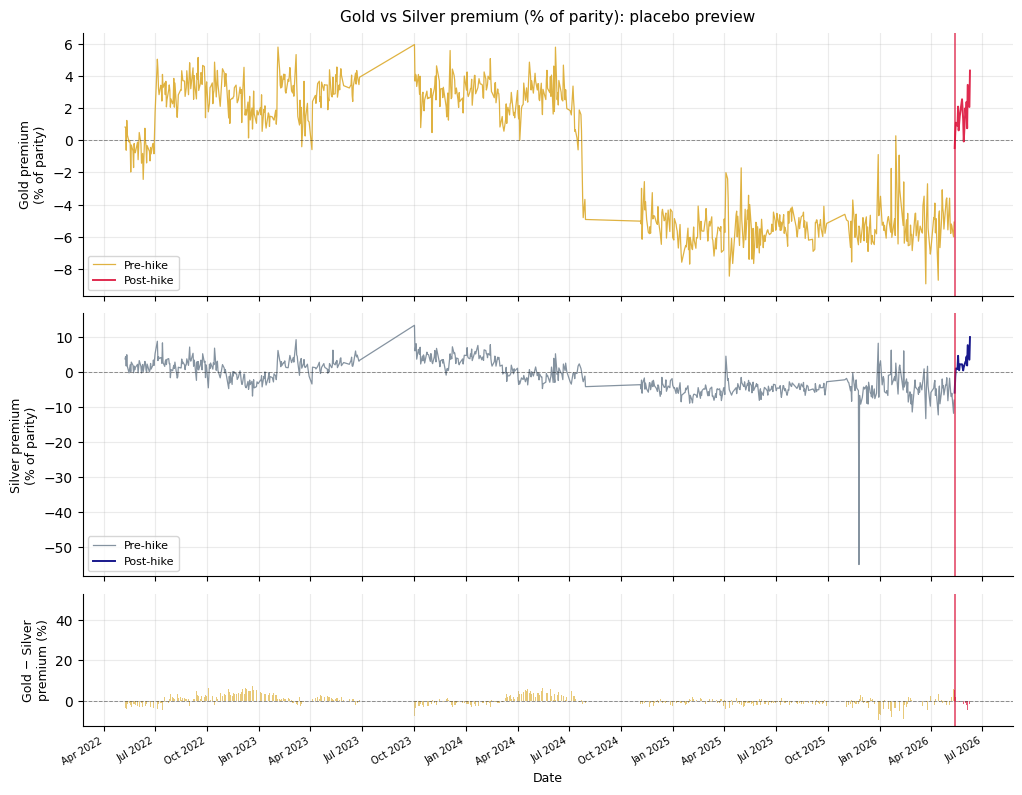

Saved → ../figures/fig08_placebo_silver.png

--- Pre/post means: gold vs silver premium (% of parity) ---

  Gold premium_pct
    Pre-hike  n= 751  mean=-0.791%  std=4.137%
    Post-hike n= 18  mean=+1.527%  std=1.192%
    Shift: +2.319 percentage points

  Silver premium_pct
    Pre-hike  n= 751  mean=-1.218%  std=4.509%
    Post-hike n= 18  mean=+2.171%  std=3.375%
    Shift: +3.388 percentage points

--- Placebo check: does silver premium jump on May 13? ---
  2026-05-13  gold=-0.486%  silver=-5.952%  diff=+5.467%
  2026-05-14  gold=+0.450%  silver=-1.441%  diff=+1.891%
  2026-05-15  gold=+1.092%  silver=+0.952%  diff=+0.140%
  2026-05-18  gold=+0.891%  silver=+0.793%  diff=+0.098%
  2026-05-19  gold=+2.088%  silver=+4.546%  diff=-2.458%


In [14]:
# ── Cell 9: Silver premium vs gold premium — placebo preview ─────────────
# Placebo logic:
#   The May 13 duty hike targeted gold specifically (BCD 6%→15%).
#   Silver import duty did NOT change on May 13.
#   If our identification is valid, gold premium should jump on May 13
#   but silver premium should NOT.
#   If silver also jumps, something else (macro shock, IBJA reporting change,
#   etc.) is driving the result — not the gold duty.
#
# This is the visual version of the placebo test.
# The formal regression placebo runs in Notebook 02.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ── Normalise both premiums to % of parity for comparability ─────────────
# Gold premium_pct already in df.
# Silver premium_pct = silver_premium / silver_parity_pre * 100
df['silver_premium_pct'] = (df['silver_premium'] / df['silver_parity_pre']) * 100

gold_pct   = df['premium_pct'].dropna()
silver_pct = df['silver_premium_pct'].dropna()

# Common date range (both non-NaN)
both = df[['premium_pct', 'silver_premium_pct']].dropna()
print(f'Common observations: {len(both)}')
print(f'Date range         : {both.index[0].date()} → {both.index[-1].date()}')

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 2, 1], 'hspace': 0.08})

# ── Panel 1: gold premium_pct ─────────────────────────────────────────────
ax1 = axes[0]
pre_gold  = both.loc[both.index < POLICY_DATE, 'premium_pct']
post_gold = both.loc[both.index >= POLICY_DATE, 'premium_pct']
ax1.plot(pre_gold.index,  pre_gold.values,  color='goldenrod', linewidth=0.9,
         alpha=0.85, label='Pre-hike')
ax1.plot(post_gold.index, post_gold.values, color='crimson',   linewidth=1.4,
         alpha=0.9,  label='Post-hike')
ax1.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax1.axvline(POLICY_DATE, color='crimson', linewidth=1.3, alpha=0.7)
ax1.set_ylabel('Gold premium\n(% of parity)', fontsize=9)
ax1.set_title('Gold vs Silver premium (% of parity): placebo preview', fontsize=11, pad=8)
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)

# ── Panel 2: silver premium_pct ───────────────────────────────────────────
ax2 = axes[1]
pre_silver  = both.loc[both.index < POLICY_DATE, 'silver_premium_pct']
post_silver = both.loc[both.index >= POLICY_DATE, 'silver_premium_pct']
ax2.plot(pre_silver.index,  pre_silver.values,  color='slategray', linewidth=0.9,
         alpha=0.85, label='Pre-hike')
ax2.plot(post_silver.index, post_silver.values, color='navy',      linewidth=1.4,
         alpha=0.9,  label='Post-hike')
ax2.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax2.axvline(POLICY_DATE, color='crimson', linewidth=1.3, alpha=0.7)
ax2.set_ylabel('Silver premium\n(% of parity)', fontsize=9)
ax2.legend(fontsize=8, loc='lower left')
ax2.grid(alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

# ── Panel 3: difference (gold_pct - silver_pct) ───────────────────────────
ax3 = axes[2]
diff = both['premium_pct'] - both['silver_premium_pct']
pre_diff  = diff[diff.index < POLICY_DATE]
post_diff = diff[diff.index >= POLICY_DATE]
ax3.bar(pre_diff.index,  pre_diff.values,  width=1, color='goldenrod', alpha=0.6)
ax3.bar(post_diff.index, post_diff.values, width=1, color='crimson',   alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax3.axvline(POLICY_DATE, color='crimson', linewidth=1.3, alpha=0.7)
ax3.set_ylabel('Gold − Silver\npremium (%)', fontsize=9)
ax3.set_xlabel('Date', fontsize=9)
ax3.grid(alpha=0.25)
ax3.spines[['top','right']].set_visible(False)
ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

plt.tight_layout()
out = FIG_DIR / 'fig08_placebo_silver.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

# ── Numeric summary ───────────────────────────────────────────────────────
print('\n--- Pre/post means: gold vs silver premium (% of parity) ---')
for label, col in [('Gold premium_pct', 'premium_pct'),
                   ('Silver premium_pct', 'silver_premium_pct')]:
    pre  = both.loc[both.index < POLICY_DATE,  col]
    post = both.loc[both.index >= POLICY_DATE, col]
    print(f'\n  {label}')
    print(f'    Pre-hike  n={len(pre):>4}  mean={pre.mean():+.3f}%  std={pre.std():.3f}%')
    print(f'    Post-hike n={len(post):>3}  mean={post.mean():+.3f}%  std={post.std():.3f}%')
    print(f'    Shift: {post.mean() - pre.mean():+.3f} percentage points')

print('\n--- Placebo check: does silver premium jump on May 13? ---')
for days_offset in [0, 1, 2, 3, 4]:
    date = POLICY_DATE + pd.tseries.offsets.BDay(days_offset)
    if date in both.index:
        g = both.loc[date, 'premium_pct']
        s = both.loc[date, 'silver_premium_pct']
        print(f'  {date.date()}  gold={g:+.3f}%  silver={s:+.3f}%  diff={g-s:+.3f}%')